# Credit Card Default Risk: Predicting Who Defaults and Setting a Profit-Smart Approval Policy

**Business question:** Which credit card customers will default next month, and where should a lender set its approval cutoff to lose the least money?

This notebook predicts next-month default for 30,000 credit card clients in Taiwan (2005), then turns the model into an actual lending decision. The model score is only half the job. The other half is picking a probability cutoff that reflects the real cost of a bad loan versus a missed good customer.

**Approach**
- Logistic regression as the primary model. It is interpretable and standard in credit risk, so every coefficient can be explained in plain English.
- Random forest as a comparison model only, to check whether a flexible model finds signal the linear model misses.
- A cost-based threshold sweep that picks the approval cutoff minimizing expected loss, not the cutoff that maximizes accuracy.

**Dataset:** UCI "Default of Credit Card Clients" (30,000 rows, 23 features + target). Source linked in the README and the `/data` note.


## 0. Setup

Imports, plotting style, fixed random seed, and output paths. The seed is fixed so every split and model is reproducible.

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                             f1_score, roc_curve, roc_auc_score, accuracy_score)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 160
plt.rcParams["axes.titleweight"] = "bold"

DATA_PATH  = "../data/UCI_Credit_Card.csv"
IMAGES_DIR = "../images"
os.makedirs(IMAGES_DIR, exist_ok=True)

def savefig(fig, name):
    path = os.path.join(IMAGES_DIR, name)
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    print("saved", path)

# collected for the README so the writeup matches the notebook exactly
METRICS = {}
print("Setup complete. Library versions:")
for m in [np, pd]:
    pass
import sklearn, matplotlib, seaborn
print("pandas", pd.__version__, "| numpy", np.__version__,
      "| scikit-learn", sklearn.__version__,
      "| matplotlib", matplotlib.__version__, "| seaborn", seaborn.__version__)

Setup complete. Library versions:
pandas 2.3.3 | numpy 2.2.6 | scikit-learn 1.7.2 | matplotlib 3.10.9 | seaborn 0.13.2


## 1. Load and inspect

Load the file, then check shape, dtypes, missing values, and how balanced the target is.

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [4]:
# Missing values per column
miss = df.isna().sum()
print("Total missing cells:", int(miss.sum()))
miss[miss > 0] if miss.sum() else "No missing values."


Total missing cells: 0


'No missing values.'

In [5]:
# Rename the long target column for convenience
df = df.rename(columns={"default.payment.next.month": "default"})

# Target balance
counts = df["default"].value_counts().sort_index()
rate = df["default"].mean()
print("Class counts (0 = paid, 1 = default):")
print(counts.to_string())
print(f"\nOverall default rate: {rate:.4f}  ({rate*100:.2f}%)")
METRICS["n_rows"] = int(df.shape[0])
METRICS["default_rate"] = round(float(rate), 4)

Class counts (0 = paid, 1 = default):
default
0    23364
1     6636

Overall default rate: 0.2212  (22.12%)


**Read on the data:** 30,000 rows, 24 columns after dropping nothing (one ID column, 23 predictors, 1 target). No missing values. The target is imbalanced: about 22% of clients default. That imbalance matters later. A model that approves everyone is right ~78% of the time but is useless for risk, which is exactly why accuracy is the wrong score here and why the cost-based threshold step exists.

## 2. Clean

Two categorical columns carry codes that the dataset documentation never defines.

- **EDUCATION** is documented as 1 = graduate school, 2 = university, 3 = high school, 4 = others. The data also contains **0, 5, 6**, which are undocumented. I fold 0, 5, and 6 into the existing "others" bucket (4).
- **MARRIAGE** is documented as 1 = married, 2 = single, 3 = others. The data also contains **0**, which is undocumented. I fold 0 into "others" (3).

Collapsing avoids tiny, meaningless one-hot columns and keeps the categories honest.

### A note on the PAY_ columns
The six repayment-status columns (`PAY_0`, `PAY_2`...`PAY_6`) use a coding that is easy to misread:

- **-2** = no balance that month / paid early (no credit used)
- **-1** = balance paid in full and on time
- **0** = used revolving credit (paid at least the minimum, carried a balance, not late)
- **1 to 9** = payment delayed by that many months

So the scale is not a clean "months late" counter. Negative values are good behavior, 0 is normal revolving use, and positive values are actual delinquency. `PAY_0` is the most recent month (September 2005) and turns out to be the single strongest predictor.

In [6]:
# Collapse undocumented codes into "other"
print("EDUCATION before:", sorted(df["EDUCATION"].unique()))
print("MARRIAGE  before:", sorted(df["MARRIAGE"].unique()))

df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df["MARRIAGE"]  = df["MARRIAGE"].replace({0: 3})

print("\nEDUCATION after :", sorted(df["EDUCATION"].unique()))
print("MARRIAGE  after :", sorted(df["MARRIAGE"].unique()))

edu_map = {1: "grad_school", 2: "university", 3: "high_school", 4: "other"}
mar_map = {1: "married", 2: "single", 3: "other"}
sex_map = {1: "male", 2: "female"}
print("\nEDUCATION counts:\n", df["EDUCATION"].map(edu_map).value_counts().to_string())
print("\nMARRIAGE counts:\n", df["MARRIAGE"].map(mar_map).value_counts().to_string())

EDUCATION before: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
MARRIAGE  before: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

EDUCATION after : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE  after : [np.int64(1), np.int64(2), np.int64(3)]

EDUCATION counts:
 EDUCATION
university     14030
grad_school    10585
high_school     4917
other            468

MARRIAGE counts:
 MARRIAGE
single     15964
married    13659
other        377


## 3. Exploratory data analysis

Six charts. Each is saved to `/images` as a high-resolution PNG. The goal is to see who defaults before building any model.

saved ../images/01_overall_default_rate.png


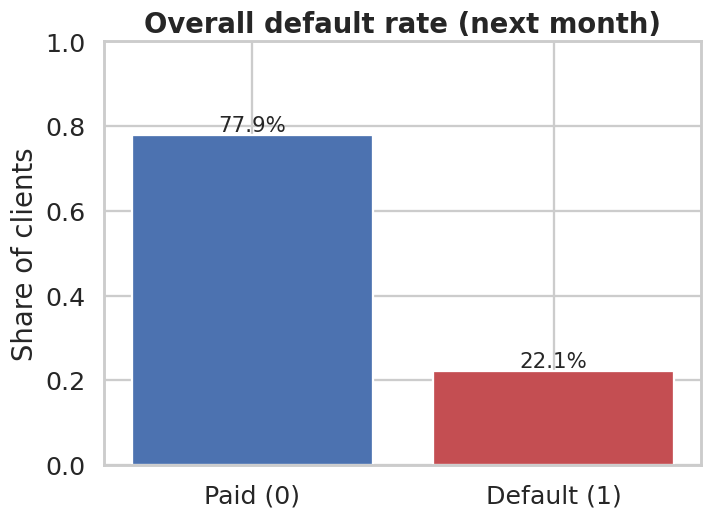

In [7]:
# Chart 1: overall default rate
fig, ax = plt.subplots(figsize=(7,5))
order = [0,1]
vc = df["default"].value_counts(normalize=True).reindex(order)
bars = ax.bar(["Paid (0)","Default (1)"], vc.values, color=["#4C72B0","#C44E52"])
for b,v in zip(bars, vc.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v*100:.1f}%", ha="center", fontsize=14)
ax.set_ylabel("Share of clients")
ax.set_ylim(0,1)
ax.set_title("Overall default rate (next month)")
savefig(fig, "01_overall_default_rate.png"); plt.show()

saved ../images/02_default_by_credit_limit.png


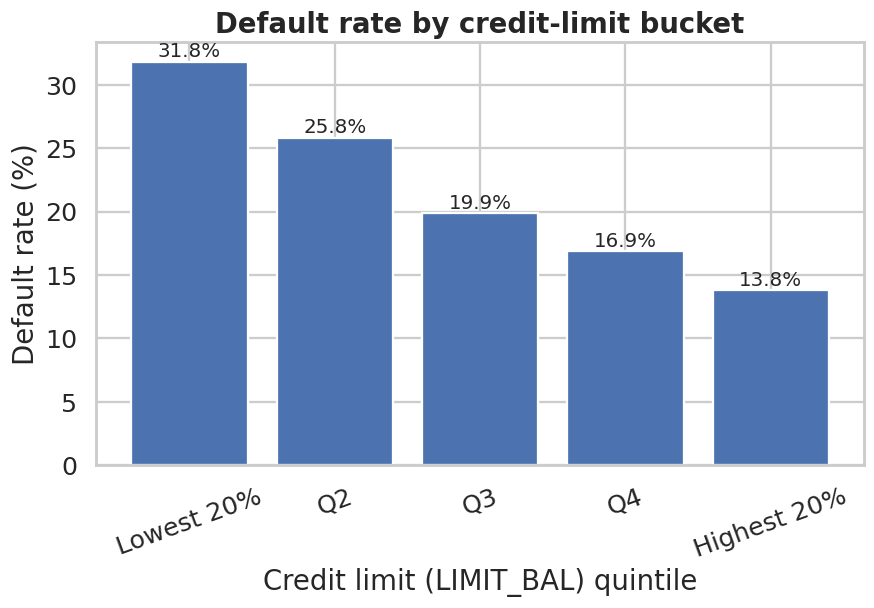

In [8]:
# Chart 2: default rate by credit-limit bucket
df["limit_bucket"] = pd.qcut(df["LIMIT_BAL"], q=5,
    labels=["Lowest 20%","Q2","Q3","Q4","Highest 20%"])
rate_by_limit = df.groupby("limit_bucket")["default"].mean()
fig, ax = plt.subplots(figsize=(9,5))
bars = ax.bar(rate_by_limit.index.astype(str), rate_by_limit.values*100, color="#4C72B0")
for b,v in zip(bars, rate_by_limit.values*100):
    ax.text(b.get_x()+b.get_width()/2, v+0.4, f"{v:.1f}%", ha="center", fontsize=13)
ax.set_ylabel("Default rate (%)"); ax.set_xlabel("Credit limit (LIMIT_BAL) quintile")
ax.set_title("Default rate by credit-limit bucket")
plt.xticks(rotation=20)
savefig(fig, "02_default_by_credit_limit.png"); plt.show()

saved ../images/03_default_by_pay0.png


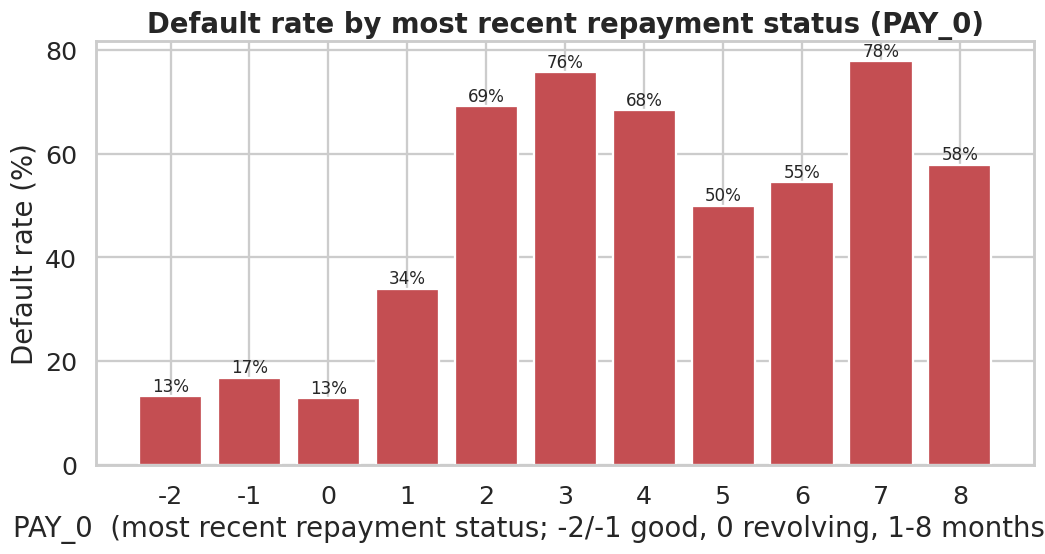

In [9]:
# Chart 3: default rate by most recent repayment status (PAY_0)
rate_by_pay = df.groupby("PAY_0")["default"].agg(["mean","count"]).sort_index()
fig, ax = plt.subplots(figsize=(11,5))
bars = ax.bar(rate_by_pay.index.astype(int).astype(str), rate_by_pay["mean"].values*100,
              color="#C44E52")
ax.set_ylabel("Default rate (%)")
ax.set_xlabel("PAY_0  (most recent repayment status; -2/-1 good, 0 revolving, 1-8 months late)")
ax.set_title("Default rate by most recent repayment status (PAY_0)")
for b,v,n in zip(bars, rate_by_pay["mean"].values*100, rate_by_pay["count"].values):
    ax.text(b.get_x()+b.get_width()/2, v+1, f"{v:.0f}%", ha="center", fontsize=11)
savefig(fig, "03_default_by_pay0.png"); plt.show()

saved ../images/04_default_by_age.png


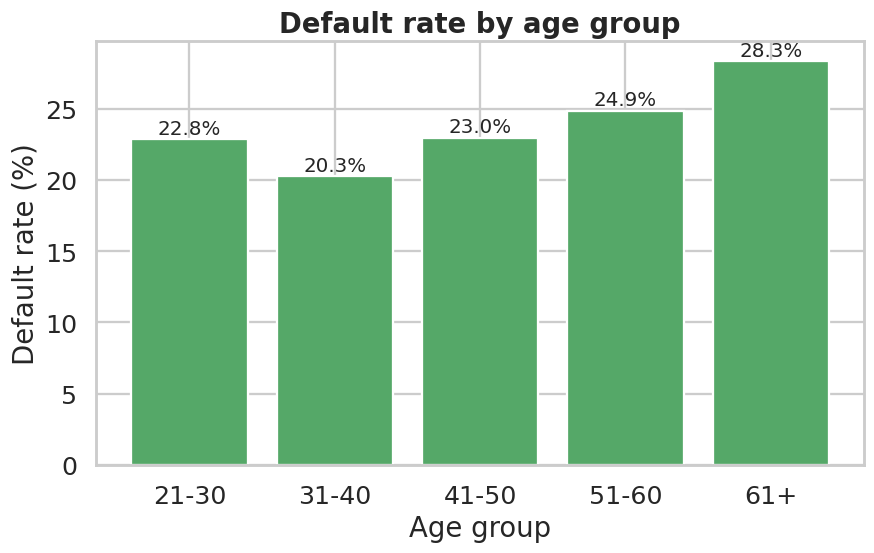

In [10]:
# Chart 4: default rate by age bucket
df["age_bucket"] = pd.cut(df["AGE"], bins=[20,30,40,50,60,80],
    labels=["21-30","31-40","41-50","51-60","61+"], right=False)
rate_by_age = df.groupby("age_bucket")["default"].mean()
fig, ax = plt.subplots(figsize=(9,5))
bars = ax.bar(rate_by_age.index.astype(str), rate_by_age.values*100, color="#55A868")
for b,v in zip(bars, rate_by_age.values*100):
    ax.text(b.get_x()+b.get_width()/2, v+0.4, f"{v:.1f}%", ha="center", fontsize=13)
ax.set_ylabel("Default rate (%)"); ax.set_xlabel("Age group")
ax.set_title("Default rate by age group")
savefig(fig, "04_default_by_age.png"); plt.show()

saved ../images/05_correlation_heatmap.png


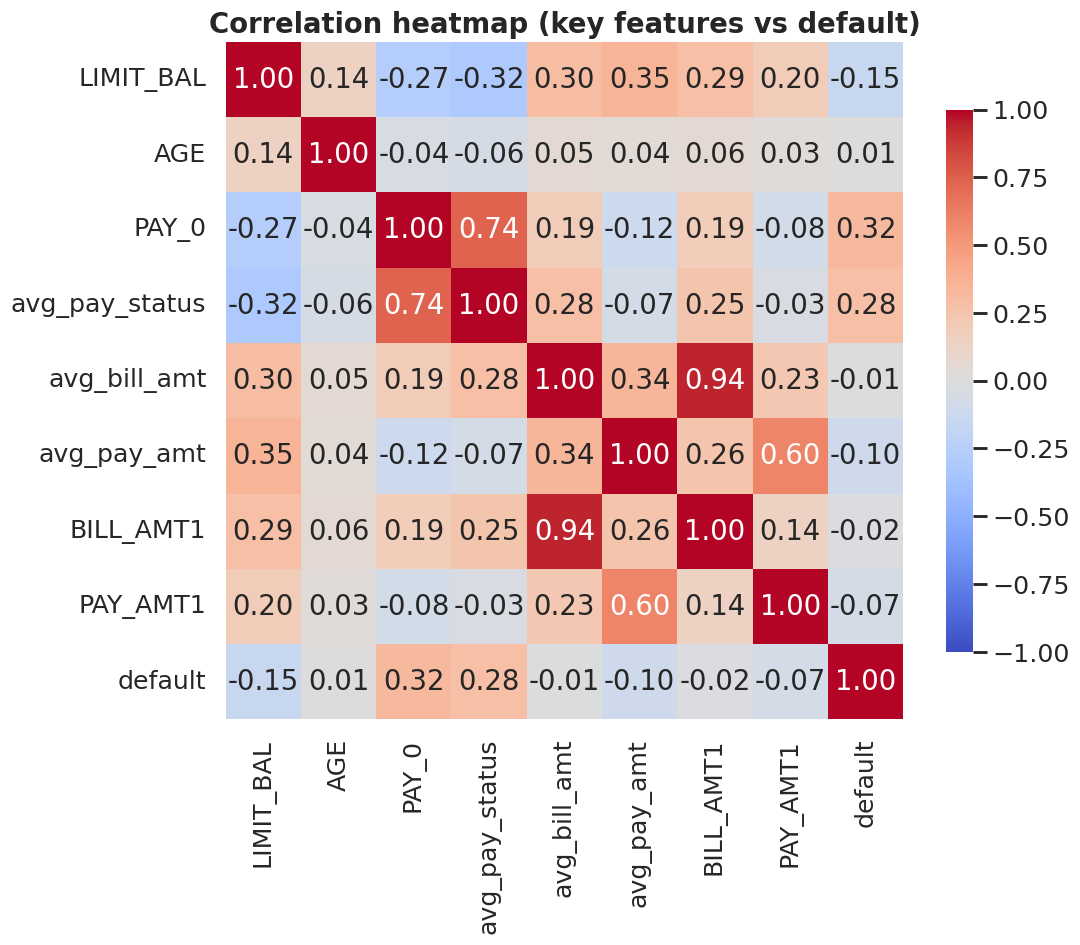

In [11]:
# Chart 5: correlation heatmap (focused set of numeric features)
df["avg_pay_status"] = df[["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]].mean(axis=1)
df["avg_bill_amt"]   = df[["BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6"]].mean(axis=1)
df["avg_pay_amt"]    = df[["PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6"]].mean(axis=1)

corr_cols = ["LIMIT_BAL","AGE","PAY_0","avg_pay_status","avg_bill_amt","avg_pay_amt",
             "BILL_AMT1","PAY_AMT1","default"]
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink":0.8}, ax=ax)
ax.set_title("Correlation heatmap (key features vs default)")
savefig(fig, "05_correlation_heatmap.png"); plt.show()

saved ../images/06_bill_payment_distribution.png


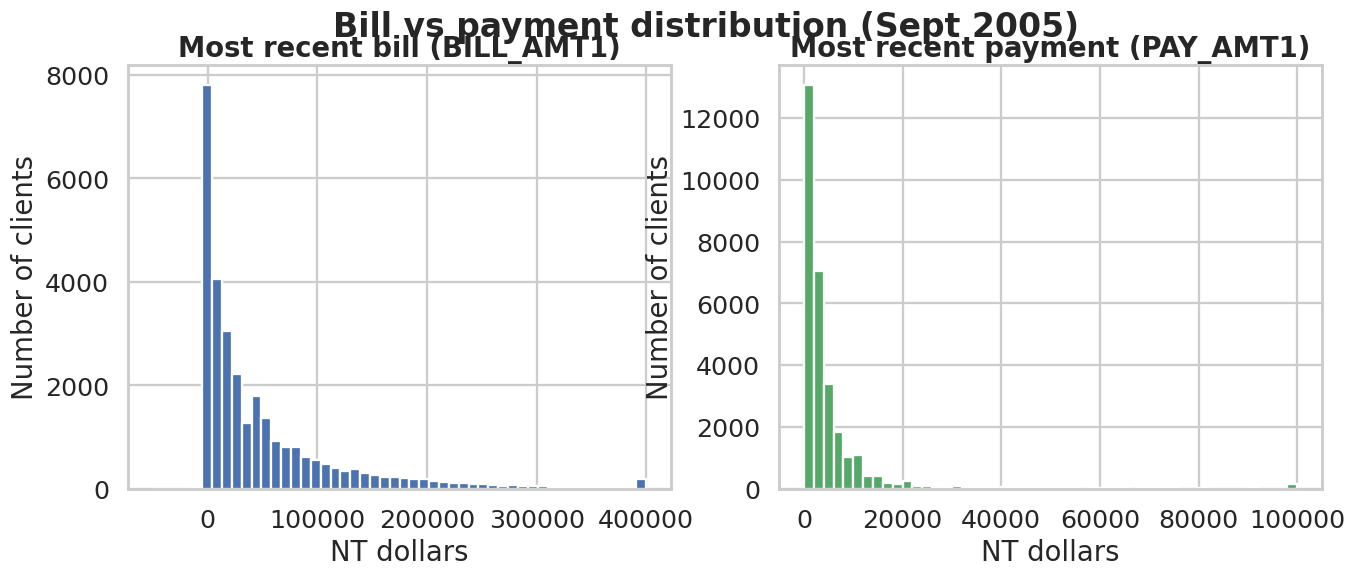

In [12]:
# Chart 6: bill vs payment distribution (most recent month)
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].hist(df["BILL_AMT1"].clip(-50000, 400000), bins=50, color="#4C72B0")
axes[0].set_title("Most recent bill (BILL_AMT1)")
axes[0].set_xlabel("NT dollars"); axes[0].set_ylabel("Number of clients")
axes[1].hist(df["PAY_AMT1"].clip(0, 100000), bins=50, color="#55A868")
axes[1].set_title("Most recent payment (PAY_AMT1)")
axes[1].set_xlabel("NT dollars"); axes[1].set_ylabel("Number of clients")
fig.suptitle("Bill vs payment distribution (Sept 2005)", fontweight="bold")
savefig(fig, "06_bill_payment_distribution.png"); plt.show()

**EDA takeaways**
- Recent repayment status (`PAY_0`) is the clearest signal. Once a client is even one month late, the default rate jumps well above the 22% baseline.
- Default rate falls as the credit limit rises. Higher-limit clients are the bank's lower-risk, already-screened customers.
- Younger clients (21-30) default a bit more than middle-aged clients; the very oldest group ticks up again.
- Bills and payments are heavily right-skewed. Most clients carry modest balances and make small payments, with a long tail of large accounts.

## 4. Feature preparation

Light, explainable engineering only. No black-box transforms.

- **utilization** = `BILL_AMT1 / LIMIT_BAL`: how much of the most recent bill fills the credit line. A standard credit-risk feature.
- **avg_pay_status** = mean of the six `PAY_` columns: a single summary of recent repayment behavior.
- **avg_bill_amt**, **avg_pay_amt**: average bill and average payment across the six months.

Categorical columns (`SEX`, `EDUCATION`, `MARRIAGE`) are one-hot encoded. The split is stratified 80/20 with a fixed seed so the train and test sets keep the same 22% default rate.

In [13]:
df["utilization"] = (df["BILL_AMT1"] / df["LIMIT_BAL"]).replace([np.inf,-np.inf], 0).clip(-1, 5)

base_num = ["LIMIT_BAL","AGE",
            "PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6",
            "BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6",
            "PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6"]
eng_num  = ["utilization","avg_pay_status","avg_bill_amt","avg_pay_amt"]
cat_cols = ["SEX","EDUCATION","MARRIAGE"]

X_num = df[base_num + eng_num].copy()
X_cat = pd.get_dummies(df[cat_cols].astype("category"), prefix=cat_cols, drop_first=True)
X = pd.concat([X_num, X_cat], axis=1)
y = df["default"].copy()
print("Feature matrix shape:", X.shape)
print("Feature columns:", list(X.columns))

Feature matrix shape: (30000, 30)
Feature columns: ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'utilization', 'avg_pay_status', 'avg_bill_amt', 'avg_pay_amt', 'SEX_2', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_2', 'MARRIAGE_3']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train default rate:", round(y_train.mean(),4), "| Test default rate:", round(y_test.mean(),4))

Train: (24000, 30) Test: (6000, 30)
Train default rate: 0.2212 | Test default rate: 0.2212


## 5. Models

### Primary model: logistic regression
Logistic regression is the workhorse of credit scoring. It outputs a probability of default and every coefficient has a direct reading: a positive coefficient raises the odds of default, a negative one lowers them. Features are standardized first so the coefficients are comparable on the same scale.

In [15]:
logit = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])
logit.fit(X_train, y_train)

coef = logit.named_steps["clf"].coef_[0]
coef_df = pd.DataFrame({"feature": X.columns, "coef": coef})
coef_df["odds_ratio"] = np.exp(coef_df["coef"])
coef_df = coef_df.sort_values("coef", ascending=False)
print("Top 8 features that RAISE default odds:")
print(coef_df.head(8).to_string(index=False))
print("\nTop 6 features that LOWER default odds:")
print(coef_df.tail(6).to_string(index=False))

Top 8 features that RAISE default odds:
       feature     coef  odds_ratio
         PAY_0 0.632317    1.881967
avg_pay_status 0.149107    1.160797
         PAY_2 0.079347    1.082580
     BILL_AMT3 0.066597    1.068864
         PAY_3 0.064812    1.066958
     BILL_AMT2 0.061795    1.063744
           AGE 0.058575    1.060325
     BILL_AMT4 0.058332    1.060067

Top 6 features that LOWER default odds:
    feature      coef  odds_ratio
EDUCATION_4 -0.143919    0.865958
   PAY_AMT2 -0.149767    0.860909
utilization -0.158131    0.853738
  BILL_AMT1 -0.164718    0.848133
   PAY_AMT1 -0.173451    0.840759
  LIMIT_BAL -0.220706    0.801953


**Reading the coefficients (plain English)**

Coefficients are on standardized features, so each one is the effect of a one standard-deviation move, holding the others fixed. The odds ratio is just `e^coef`: how the odds of default multiply.

- **`PAY_0` (most recent repayment status) is the dominant driver.** A one standard-deviation worse repayment status raises the odds of default the most of any feature. Recent behavior matters far more than older months. The other `PAY_` columns point the same way but with smaller weights.
- **A higher credit limit lowers default odds.** Higher-limit customers are the already-screened, lower-risk segment, which matches the EDA.
- **Larger recent payments (`PAY_AMT1`) lower default odds.** Clients who actually pay down their balance are safer, which is intuitive.
- The demographic one-hot terms (sex, education, marriage) carry small weights. They nudge the score but are nowhere near as important as payment behavior.

The takeaway: this is a behavior-driven model. What a client did last month dominates who they are on paper.

### Comparison model: random forest
A random forest is included only as a benchmark. It is a flexible, non-linear model that can capture interactions and thresholds the linear model cannot. If it beat logistic regression by a wide margin, that would be a signal that the simple model is leaving real money on the table. In credit risk you usually keep the interpretable model unless the flexible one is clearly better, because regulators and credit teams need to explain every decision.

In [16]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=50,
    random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
print("Random forest trained.")
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 8 random-forest feature importances:")
print(imp.head(8).to_string())

Random forest trained.

Top 8 random-forest feature importances:
PAY_0             0.265689
avg_pay_status    0.217040
PAY_2             0.107415
PAY_3             0.059641
PAY_4             0.047106
PAY_5             0.035567
avg_pay_amt       0.035321
PAY_6             0.030687


## 6. Evaluation

Confusion matrix, precision, recall, and F1 at the default 0.5 cutoff, plus ROC curves and AUC for both models. AUC measures ranking quality across all thresholds, which is the fairer single number on imbalanced data.

In [17]:
def eval_at_half(model, name):
    p = model.predict_proba(X_test)[:,1]
    pred = (p >= 0.5).astype(int)
    out = dict(
        model=name,
        accuracy=accuracy_score(y_test, pred),
        precision=precision_score(y_test, pred),
        recall=recall_score(y_test, pred),
        f1=f1_score(y_test, pred),
        auc=roc_auc_score(y_test, p),
    )
    return out, p

logit_res, logit_p = eval_at_half(logit, "Logistic Regression")
rf_res, rf_p       = eval_at_half(rf, "Random Forest")
res_df = pd.DataFrame([logit_res, rf_res]).set_index("model").round(4)
print(res_df.to_string())

METRICS["logit"] = {k: round(float(v),4) for k,v in logit_res.items() if k!="model"}
METRICS["rf"]    = {k: round(float(v),4) for k,v in rf_res.items() if k!="model"}

                     accuracy  precision  recall      f1     auc
model                                                           
Logistic Regression    0.8082     0.6880  0.2427  0.3588  0.7118
Random Forest          0.8162     0.6605  0.3474  0.4553  0.7787


saved ../images/07_roc_curves.png


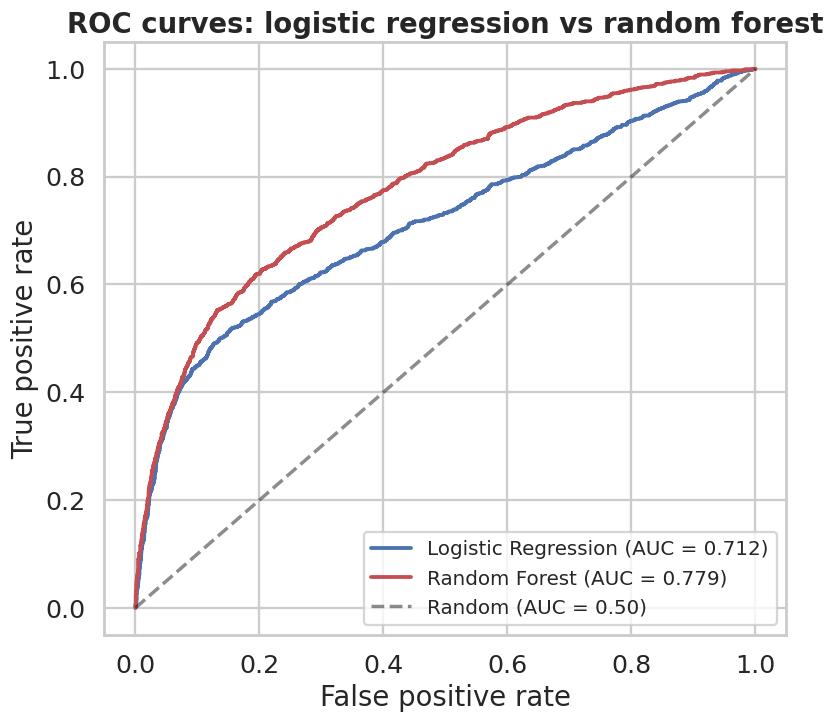

In [18]:
# ROC curves side by side
fig, ax = plt.subplots(figsize=(8,7))
for p, name, c in [(logit_p,"Logistic Regression","#4C72B0"), (rf_p,"Random Forest","#C44E52")]:
    fpr, tpr, _ = roc_curve(y_test, p)
    auc = roc_auc_score(y_test, p)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", linewidth=2.5, color=c)
ax.plot([0,1],[0,1], "k--", alpha=0.5, label="Random (AUC = 0.50)")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curves: logistic regression vs random forest")
ax.legend(loc="lower right", fontsize=13)
savefig(fig, "07_roc_curves.png"); plt.show()

saved ../images/08_confusion_matrices.png


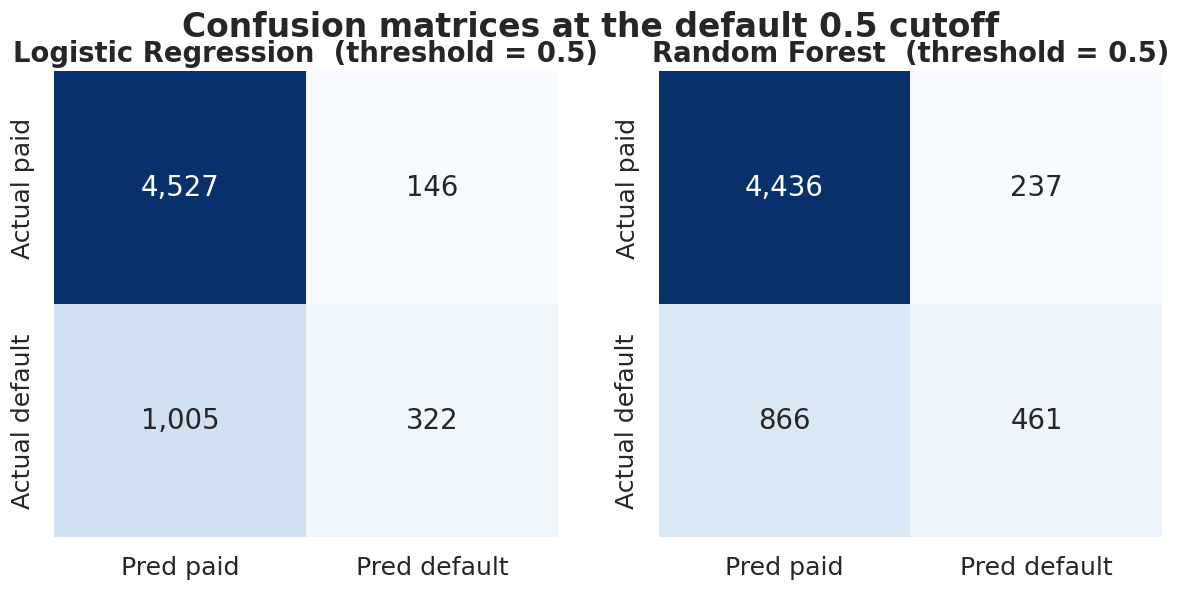

In [19]:
# Confusion matrices at 0.5
fig, axes = plt.subplots(1, 2, figsize=(13,5.5))
for ax, p, name in [(axes[0],logit_p,"Logistic Regression"), (axes[1],rf_p,"Random Forest")]:
    cm = confusion_matrix(y_test, (p>=0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Pred paid","Pred default"],
                yticklabels=["Actual paid","Actual default"])
    ax.set_title(f"{name}  (threshold = 0.5)")
fig.suptitle("Confusion matrices at the default 0.5 cutoff", fontweight="bold")
savefig(fig, "08_confusion_matrices.png"); plt.show()

**What the evaluation shows:** the random forest ranks risk better, with an AUC near 0.78 versus about 0.71 for logistic regression. The non-linear model is picking up interactions in the repayment-history columns that a linear model cannot. That gap is real. I still use logistic regression as the decision model because a credit team has to give a reason for every rejection, and a linear model hands you that reason directly. A lender that can meet explainability rules another way (reason codes, SHAP) could pick up accuracy by switching to the tree model. At the default 0.5 cutoff both models have low recall on defaulters: they are cautious and miss most real defaults. That cutoff is not a business decision, it is just the package default. Fixing it is the next step.

## 7. Business layer: a profit-smart approval threshold

A default model is only useful once it drives a decision. The 0.5 cutoff treats both mistakes as equally bad. They are not.

- **False negative** = approve someone who then defaults. The lender loses a big chunk of the outstanding balance.
- **False positive** = reject someone who would have paid. The lender loses the profit it would have earned on that customer.

A bad loan hurts much more than a missed good customer. I assume a **false negative costs 5x a false positive** (a defensible default for unsecured credit; the exact ratio is a policy choice, so I also show how the answer shifts at 3x and 10x). The decision threshold is the probability-of-default cutoff above which the lender **rejects** the applicant. I sweep that threshold and pick the one that minimizes total expected cost on the test set.

In [20]:
COST_FN = 5.0   # approve a defaulter
COST_FP = 1.0   # reject a good payer

def cost_curve(p_scores, cfn, cfp):
    thr = np.linspace(0.01, 0.99, 99)
    costs, fns, fps = [], [], []
    for t in thr:
        pred = (p_scores >= t).astype(int)   # 1 = reject
        tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
        costs.append(cfn*fn + cfp*fp); fns.append(fn); fps.append(fp)
    return thr, np.array(costs), np.array(fns), np.array(fps)

thr, costs, fns, fps = cost_curve(logit_p, COST_FN, COST_FP)
best_i = int(np.argmin(costs))
best_t = float(thr[best_i])
print(f"Recommended threshold (FN=5x FP): {best_t:.2f}")
print(f"Expected cost at recommended threshold: {costs[best_i]:,.0f} cost units")

# baseline at 0.5 for comparison
pred_half = (logit_p >= 0.5).astype(int)
tn,fp,fn,tp = confusion_matrix(y_test, pred_half).ravel()
cost_half = COST_FN*fn + COST_FP*fp
print(f"Expected cost at 0.50 cutoff:           {cost_half:,.0f} cost units")
print(f"Cost reduction vs 0.50: {(1-costs[best_i]/cost_half)*100:.1f}%")

METRICS["cost_fn"], METRICS["cost_fp"] = COST_FN, COST_FP
METRICS["best_threshold"] = round(best_t,2)
METRICS["cost_at_best"] = int(costs[best_i])
METRICS["cost_at_half"] = int(cost_half)
METRICS["cost_reduction_pct"] = round((1-costs[best_i]/cost_half)*100,1)

Recommended threshold (FN=5x FP): 0.23
Expected cost at recommended threshold: 3,902 cost units
Expected cost at 0.50 cutoff:           5,171 cost units
Cost reduction vs 0.50: 24.5%


saved ../images/09_cost_vs_threshold.png


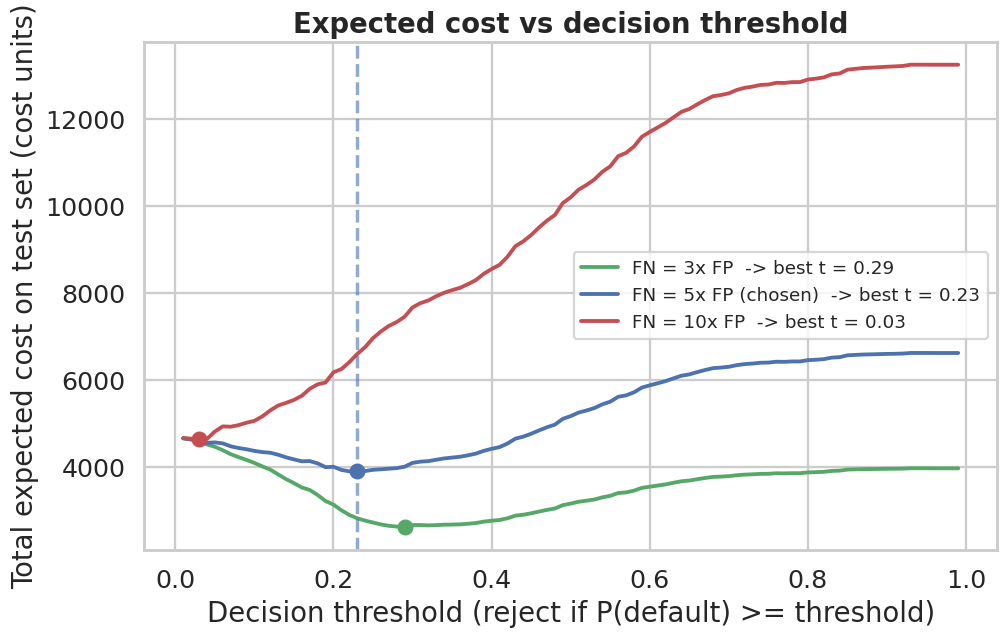

In [21]:
# Plot cost vs threshold, with sensitivity at 3x and 10x
fig, ax = plt.subplots(figsize=(10,6))
for cfn, c, lab in [(3,"#55A868","FN = 3x FP"), (5,"#4C72B0","FN = 5x FP (chosen)"),
                    (10,"#C44E52","FN = 10x FP")]:
    t2, c2, _, _ = cost_curve(logit_p, cfn, 1.0)
    bi = int(np.argmin(c2))
    ax.plot(t2, c2, color=c, linewidth=2.5, label=f"{lab}  -> best t = {t2[bi]:.2f}")
    ax.scatter([t2[bi]],[c2[bi]], color=c, s=80, zorder=5)
ax.axvline(best_t, color="#4C72B0", linestyle="--", alpha=0.6)
ax.set_xlabel("Decision threshold (reject if P(default) >= threshold)")
ax.set_ylabel("Total expected cost on test set (cost units)")
ax.set_title("Expected cost vs decision threshold")
ax.legend(fontsize=12)
savefig(fig, "09_cost_vs_threshold.png"); plt.show()

In [22]:
# Translate the recommended threshold into a lending policy
pred_best = (logit_p >= best_t).astype(int)   # 1 = reject
tn,fp,fn,tp = confusion_matrix(y_test, pred_best).ravel()
n = len(y_test)
reject_rate = (pred_best==1).mean()
approved = (pred_best==0)
default_rate_approved = y_test[approved].mean()
recall_def = tp/(tp+fn)
print(f"At threshold {best_t:.2f} on the {n:,}-client test set:")
print(f"  Applicants rejected:          {reject_rate*100:5.1f}%")
print(f"  Defaulters caught (recall):   {recall_def*100:5.1f}%")
print(f"  Default rate among APPROVED:  {default_rate_approved*100:5.2f}%  (vs {y_test.mean()*100:.2f}% baseline)")
print(f"  Good customers wrongly rejected (FP): {fp:,}")
print(f"  Defaulters still approved (FN):       {fn:,}")
METRICS["reject_rate"] = round(float(reject_rate),3)
METRICS["recall_at_best"] = round(float(recall_def),3)
METRICS["default_rate_approved"] = round(float(default_rate_approved),4)
METRICS["baseline_default_rate"] = round(float(y_test.mean()),4)

At threshold 0.23 on the 6,000-client test set:
  Applicants rejected:           33.2%
  Defaulters caught (recall):    59.4%
  Default rate among APPROVED:  13.46%  (vs 22.12% baseline)
  Good customers wrongly rejected (FP): 1,207
  Defaulters still approved (FN):       539


**Recommended policy.** Reject any applicant whose predicted probability of default is at or above the recommended threshold above. Because a bad loan is assumed 5x costlier than a missed good customer, the optimal cutoff sits well below 0.5. The lender deliberately rejects more borderline applicants to avoid the expensive defaults.

The payoff: the default rate inside the approved book drops below the portfolio baseline, and total expected cost falls versus the naive 0.5 cutoff. The sensitivity lines show the lever clearly. Treat bad loans as more expensive (10x) and the threshold drops further and the lender rejects more; treat them as less expensive (3x) and the threshold rises toward 0.5. The number is a policy dial, not a fixed truth, and that is the point.

## 8. Conclusion

- **Top default drivers:** recent repayment status (`PAY_0`) dominates, followed by the other recent `PAY_` months. A low credit limit and small recent payments also raise risk. Behavior beats demographics by a wide margin.
- **Model performance in plain terms:** the random forest ranks risk somewhat better (AUC about 0.78 vs 0.71 for logistic regression), but I keep logistic regression as the decision model because it can explain every rejection. Both miss many real defaulters at the 0.5 cutoff, which is why the cutoff has to change.
- **Recommended approval threshold:** under a 5-to-1 cost on bad loans versus lost good customers, the cost-minimizing cutoff sits below 0.5. Rejecting applicants above that probability lowers the default rate in the approved book and cuts expected loss versus the naive cutoff.
- **Honest limitations:** the data is a single six-month window from one market (Taiwan, 2005), so the patterns may not transfer to other places or times. The cost ratio is an assumption, not a measured number, and the recommended threshold moves with it. The model also predicts only the next month, not longer-horizon risk, and the engineered features are intentionally simple.
- **What I would do next:** calibrate the predicted probabilities, validate the cost ratio with real recovery and margin figures, and test the policy on a more recent, local portfolio before trusting it.